<a href="https://colab.research.google.com/github/KP-365/Fake_news/blob/main/Trained_vs_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from pathlib import Path

if not Path("predict.py").exists():
    !git clone https://github.com/KP-365/Fake_news
    os.chdir("Fake_news")

!python3 -m pip uninstall -y torchao
!python3 -m pip install -q -r requirements.txt
!python3 -m pip uninstall -y torchvision torchaudio
!pip install -q torchvision==0.27.0

fatal: destination path 'Fake_news' already exists and is not an empty directory.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
libcuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
libraft-cu12 26.2.0 requires cuda-toolkit[cublas,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
libcuvs-cu12 26.2.0 requires cuda-toolkit[cublas,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is i

In [2]:
from predict import ID_TO_LABEL, MAX_LENGTH, load_model

model, tokenizer, device = load_model()
print(f"Checkpoint loaded on {device}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Checkpoint loaded on cuda


In [3]:
import os
import re

import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split

dataset_path = kagglehub.dataset_download(
    "saurabhshahane/fake-news-classification"
)
welfake_df = pd.read_csv(os.path.join(dataset_path, "WELFake_Dataset.csv"))

if "Unnamed: 0" in welfake_df.columns:
    welfake_df = welfake_df.drop(columns=["Unnamed: 0"])

welfake_df["title"] = welfake_df["title"].fillna("")
welfake_df = welfake_df.dropna(subset=["text"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    return re.sub(r"\s+", " ", text).strip()

welfake_df["title"] = welfake_df["title"].apply(clean_text)
welfake_df["text"] = welfake_df["text"].apply(clean_text)
welfake_df = welfake_df[welfake_df["text"].str.len() > 0]
welfake_df["content"] = (
    welfake_df["title"] + ". " + welfake_df["text"]
).str.strip(". ")
welfake_df = welfake_df.drop_duplicates(subset=["text"])

train_df, temp_df = train_test_split(
    welfake_df,
    test_size=0.3,
    stratify=welfake_df["label"],
    random_state=42,
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42,
)

print(f"Held-out test examples: {len(test_df):,}")
print(test_df["label"].value_counts().sort_index())

Using Colab cache for faster access to the 'fake-news-classification' dataset.
Held-out test examples: 9,398
label
0    5193
1    4205
Name: count, dtype: int64


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Base transformer: roberta-base with a randomly initialised classification
# head (i.e. NOT fine-tuned on WELFake). This is the "before training" baseline.
o_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    id2label={0: "real", 1: "fake"},
    label2id={"real": 0, "fake": 1},
)
# Use roberta's own tokenizer so the only difference vs the trained model is
# the fine-tuning (same architecture, same tokenizer).
o_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
o_model.to(device)
o_model.eval()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
  

In [5]:
import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

batch_size = 32
test_texts = test_df["content"].tolist()
true_labels = test_df["label"].to_numpy()


@torch.no_grad()
def evaluate_model(a_model, a_tokenizer, a_device, texts, batch_size=32):
    """Run a model over `texts` and return (predictions, confidences)."""
    a_model.eval()
    preds, confs = [], []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        encoded = a_tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LENGTH,
            padding="max_length",
            return_tensors="pt",
        )
        encoded = {name: t.to(a_device) for name, t in encoded.items()}
        logits = a_model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)
        batch_conf, batch_pred = probs.max(dim=-1)
        preds.extend(batch_pred.cpu().tolist())
        confs.extend(batch_conf.cpu().tolist())
    return np.array(preds), np.array(confs)


def score(name, y_true, y_pred):
    """Compute a comparable metrics dict for one model."""
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


# --- Trained transformer (fine-tuned on WELFake) ---
trained_pred, trained_conf = evaluate_model(
    model, tokenizer, device, test_texts, batch_size
)
trained_scores = score("Trained (fine-tuned)", true_labels, trained_pred)
print("Trained transformer\n" + "-" * 40)
print(classification_report(true_labels, trained_pred, digits=4))


Trained transformer
----------------------------------------
              precision    recall  f1-score   support

           0     0.9952    0.9971    0.9962      5193
           1     0.9964    0.9941    0.9952      4205

    accuracy                         0.9957      9398
   macro avg     0.9958    0.9956    0.9957      9398
weighted avg     0.9957    0.9957    0.9957      9398



In [6]:
# --- Base transformer (roberta-base, NOT fine-tuned) ---
base_pred, base_conf = evaluate_model(
    o_model, o_tokenizer, device, test_texts, batch_size
)
base_scores = score("Base (not fine-tuned)", true_labels, base_pred)
print("Base transformer\n" + "-" * 40)
print(classification_report(true_labels, base_pred, digits=4))


Base transformer
----------------------------------------
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      5193
           1     0.4474    1.0000    0.6182      4205

    accuracy                         0.4474      9398
   macro avg     0.2237    0.5000    0.3091      9398
weighted avg     0.2002    0.4474    0.2766      9398



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Trained vs base transformer on the held-out test set


,accuracy,precision,recall,f1,accuracy_gain
model,,,,,
Base (not fine-tuned),0.4474,0.4474,1.0000,0.6182,0.0000
Trained (fine-tuned),0.9957,0.9964,0.9941,0.9952,0.5483


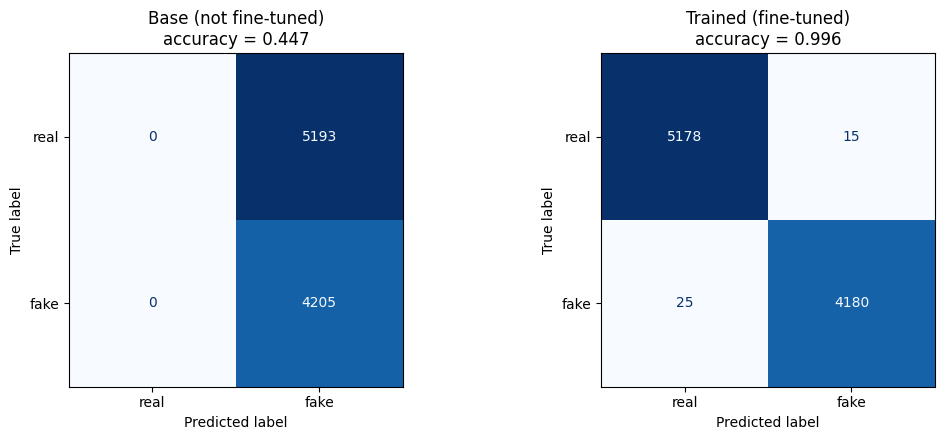

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# --- Side-by-side metrics table ---
comparison = pd.DataFrame([base_scores, trained_scores]).set_index("model")
comparison["accuracy_gain"] = (
    comparison["accuracy"] - comparison.loc["Base (not fine-tuned)", "accuracy"]
)
print("Trained vs base transformer on the held-out test set")
print("=" * 60)
display(comparison.style.format("{:.4f}"))

# --- Confusion matrices side by side ---
labels = [0, 1]
display_labels = [ID_TO_LABEL[i] for i in labels]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, preds) in zip(
    axes,
    [("Base (not fine-tuned)", base_pred), ("Trained (fine-tuned)", trained_pred)],
):
    cm = confusion_matrix(true_labels, preds, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=display_labels).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    acc = accuracy_score(true_labels, preds)
    ax.set_title(f"{title}\naccuracy = {acc:.3f}")
plt.tight_layout()
plt.show()
